### Movie Rating Analysis

In [3]:
import pandas as pd
import random
from faker import Faker

fake = Faker()
movies = ["Inception", "The Godfather", "Finding Nemo", "Avengers", "Titanic", "Shrek", "Interstellar", "Pulp Fiction"]
genres = {
    "Inception": "Sci-Fi",
    "The Godfather": "Crime",
    "Finding Nemo": "Animation",
    "Avengers": "Action",
    "Titanic": "Romance",
    "Shrek": "Comedy",
    "Interstellar": "Sci-Fi",
    "Pulp Fiction": "Crime"
}

data = []
for _ in range(2000):
    movie = random.choice(movies)
    row = {
        "UserID": random.randint(100, 999),
        "Movie": movie,
        "Genre": genres[movie],
        "Rating": round(random.uniform(1, 5), 1),
        "Timestamp": fake.date_between(start_date='-2y', end_date='today')
    }
    data.append(row)

df = pd.DataFrame(data)
df.to_csv("movie_ratings.csv", index=False)


### Read CSV and Parse Timestamp

In [15]:

# Read CSV and parse Timestamp as datetime
df = pd.read_csv("movie_ratings.csv", parse_dates=["Timestamp"])

# Display data types to confirm
print(df.dtypes)

# Show first few rows
print(df.head())


UserID                int64
Movie                object
Genre                object
Rating              float64
Timestamp    datetime64[ns]
dtype: object
   UserID          Movie      Genre  Rating  Timestamp
0     105  The Godfather      Crime     2.0 2024-05-17
1     733        Titanic    Romance     2.6 2024-11-13
2     623   Finding Nemo  Animation     3.8 2023-09-16
3     510        Titanic    Romance     3.3 2024-10-17
4     134   Interstellar     Sci-Fi     1.6 2024-11-05


### Average Rating per Genre

In [14]:
# Calculate average rating per genre
genre_avg = df.groupby("Genre")["Rating"].mean()

# Display the results
print("Average rating per genre:")
print(genre_avg.sort_values(ascending=False))


Average rating per genre:
Genre
Action       3.078968
Crime        3.026042
Comedy       2.969600
Romance      2.934601
Animation    2.932558
Sci-Fi       2.903622
Name: Rating, dtype: float64


### Movie with Highest Average Rating

In [13]:
# Find the movie with the highest average rating
top_movie = df.groupby("Movie")["Rating"].mean().idxmax()

# Get its average rating
top_rating = df.groupby("Movie")["Rating"].mean().max()

# Display the result
print(f"The movie with the highest average rating is: {top_movie} ({top_rating:.2f})")


The movie with the highest average rating is: Pulp Fiction (3.12)


### Add Rating_Level Column

In [12]:
# Define function to classify rating level
def get_rating_level(rating):
    if rating < 3:
        return "Low"
    elif rating <= 4:
        return "Medium"
    return "High"

# Apply function to add a new column
df["Rating_Level"] = df["Rating"].apply(get_rating_level)

# Display the first few rows to confirm the result
print(df[["Rating", "Rating_Level"]].head())


   Rating Rating_Level
0     2.0          Low
1     2.6          Low
2     3.8       Medium
3     3.3       Medium
4     1.6          Low


### Count Ratings by Rating_Level
python
Copy
Edit


In [11]:
rating_counts = df["Rating_Level"].value_counts()
print(rating_counts)


Rating_Level
Low       988
Medium    548
High      464
Name: count, dtype: int64


### Environmental Sensor Data

### Generate 2000 Sensor Readings and Save to CSV

In [17]:

locations = ["Lab1", "Lab2", "Lab3", "Greenhouse", "Warehouse"]
sensors = ["S1", "S2", "S3", "S4", "S5"]

data = []
for _ in range(2000):
    data.append({
        "SensorID": random.choice(sensors),
        "Location": random.choice(locations),
        "Temperature": round(random.uniform(18.0, 30.0), 1),
        "Humidity": random.randint(30, 70),
        "ReadingTime": fake.date_time_between(start_date="-15d", end_date="now")
    })

env_df = pd.DataFrame(data)
env_df.to_csv("sensor_data.csv", index=False)


### Read CSV and Convert ReadingTime

In [18]:
env_df = pd.read_csv("sensor_data.csv", parse_dates=["ReadingTime"])
print(env_df.dtypes)


SensorID               object
Location               object
Temperature           float64
Humidity                int64
ReadingTime    datetime64[ns]
dtype: object


### Average Temperature per Location

In [19]:
avg_temp_per_location = env_df.groupby("Location")["Temperature"].mean()
print("Average Temperature per Location:\n", avg_temp_per_location)


Average Temperature per Location:
 Location
Greenhouse    23.876965
Lab1          24.248642
Lab2          23.903665
Lab3          23.992288
Warehouse     24.099560
Name: Temperature, dtype: float64


### Max Humidity per Sensor

In [20]:
max_humidity_per_sensor = env_df.groupby("SensorID")["Humidity"].max()
print("Max Humidity per Sensor:\n", max_humidity_per_sensor)


Max Humidity per Sensor:
 SensorID
S1    70
S2    70
S3    70
S4    70
S5    70
Name: Humidity, dtype: int64


### Add Temp_Status Column

In [21]:
env_df["Temp_Status"] = env_df["Temperature"].apply(
    lambda t: "Normal" if 20 <= t <= 25 else "Alert"
)
print(env_df[["Temperature", "Temp_Status"]].head())


   Temperature Temp_Status
0         22.5      Normal
1         28.7       Alert
2         26.4       Alert
3         28.4       Alert
4         24.9      Normal


### Resample by Hour and Calculate Mean Temperature

In [22]:
env_df.set_index("ReadingTime", inplace=True)
hourly_mean_temp = env_df["Temperature"].resample("H").mean()
print(hourly_mean_temp.head())


ReadingTime
2025-07-17 17:00:00    27.900000
2025-07-17 18:00:00    23.700000
2025-07-17 19:00:00    25.507143
2025-07-17 20:00:00    23.520000
2025-07-17 21:00:00    21.700000
Freq: h, Name: Temperature, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_14896\4228981385.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_mean_temp = env_df["Temperature"].resample("H").mean()


### Inventory & Stock Movement

### Generate 2000 Movement Logs and Save to CSV

In [23]:
items = [
    {"ItemID": 1, "ItemName": "Laptop", "Category": "Electronics"},
    {"ItemID": 2, "ItemName": "Desk", "Category": "Furniture"},
    {"ItemID": 3, "ItemName": "Chair", "Category": "Furniture"},
    {"ItemID": 4, "ItemName": "Monitor", "Category": "Electronics"},
    {"ItemID": 5, "ItemName": "Notebook", "Category": "Stationery"},
]

movements = []

for _ in range(2000):
    item = random.choice(items)
    movements.append({
        "ItemID": item["ItemID"],
        "ItemName": item["ItemName"],
        "Category": item["Category"],
        "MovementType": random.choice(["IN", "OUT"]),
        "Quantity": random.randint(1, 20),
        "Date": fake.date_between(start_date="-30d", end_date="today")
    })

inv_df = pd.DataFrame(movements)
inv_df.to_csv("inventory_movements.csv", index=False)


### Read CSV and Display Info

In [24]:
inv_df = pd.read_csv("inventory_movements.csv", parse_dates=["Date"])
print(inv_df.info())
print(inv_df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ItemID        2000 non-null   int64         
 1   ItemName      2000 non-null   object        
 2   Category      2000 non-null   object        
 3   MovementType  2000 non-null   object        
 4   Quantity      2000 non-null   int64         
 5   Date          2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 93.9+ KB
None
   ItemID ItemName     Category MovementType  Quantity       Date
0       1   Laptop  Electronics          OUT         4 2025-07-02
1       2     Desk    Furniture          OUT         9 2025-07-21
2       4  Monitor  Electronics          OUT        13 2025-07-02
3       3    Chair    Furniture          OUT        17 2025-07-22
4       2     Desk    Furniture           IN         2 2025-07-03


### Current Stock per Item

In [25]:
# Add Net Quantity: IN = +Quantity, OUT = -Quantity
inv_df["Net_Quantity"] = inv_df.apply(
    lambda row: row["Quantity"] if row["MovementType"] == "IN" else -row["Quantity"], axis=1
)

current_stock = inv_df.groupby(["ItemID", "ItemName"])["Net_Quantity"].sum()
print("Current Stock per Item:\n", current_stock)


Current Stock per Item:
 ItemID  ItemName
1       Laptop       90
2       Desk        -26
3       Chair      -367
4       Monitor     196
5       Notebook    404
Name: Net_Quantity, dtype: int64


### Category with Highest Total Stock Movement

In [26]:
total_movement_by_category = inv_df.groupby("Category")["Quantity"].sum()
top_category = total_movement_by_category.idxmax()
print(f"Category with highest total stock movement: {top_category}")


Category with highest total stock movement: Furniture


### Code to Add Net_Quantity

In [27]:
# Add Net_Quantity column
inv_df["Net_Quantity"] = inv_df.apply(
    lambda row: row["Quantity"] if row["MovementType"] == "IN" else -row["Quantity"],
    axis=1
)

# Preview the result
print(inv_df[["MovementType", "Quantity", "Net_Quantity"]].head())


  MovementType  Quantity  Net_Quantity
0          OUT         4            -4
1          OUT         9            -9
2          OUT        13           -13
3          OUT        17           -17
4           IN         2             2


### Time Series of Daily Net Movement

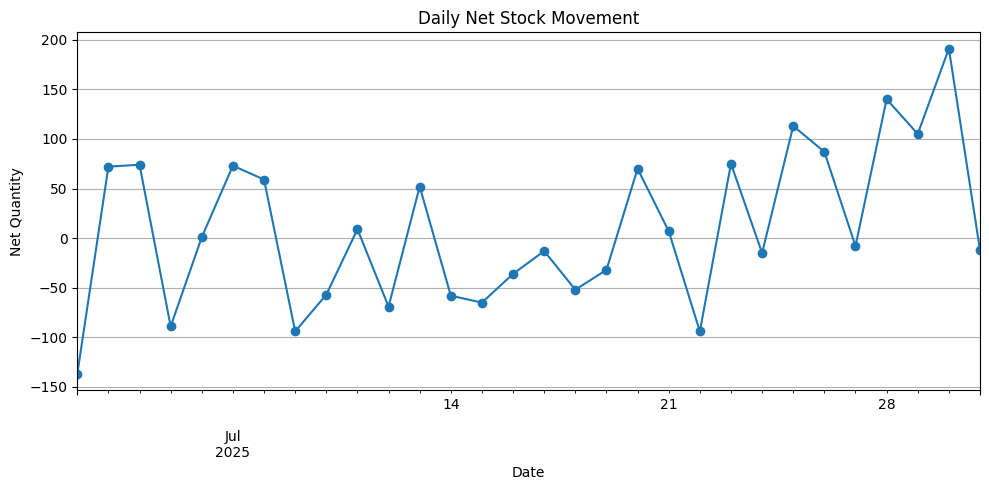

In [28]:
daily_movement = inv_df.groupby("Date")["Net_Quantity"].sum()

# Optional: Plotting
import matplotlib.pyplot as plt

daily_movement.plot(kind="line", marker="o", figsize=(10, 5), title="Daily Net Stock Movement")
plt.xlabel("Date")
plt.ylabel("Net Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()


### Website Traffic Analysis

### Generate 2000 Website Visit Records and Save to CSV

In [29]:

pages = ["Home", "About", "Contact", "Blog", "Products", "Services", "FAQ", "Careers"]
devices = ["Desktop", "Mobile", "Tablet"]

web_traffic = []
for _ in range(2000):
    web_traffic.append({
        "Date": fake.date_between(start_date="-60d", end_date="today"),
        "Page": random.choice(pages),
        "UserID": random.randint(1000, 2000),
        "SessionDuration": random.randint(10, 600),  # seconds
        "Device": random.choice(devices)
    })

web_df = pd.DataFrame(web_traffic)
web_df.to_csv("website_traffic.csv", index=False)


### Read CSV and Parse Date

In [30]:
web_df = pd.read_csv("website_traffic.csv", parse_dates=["Date"])
print(web_df.dtypes)


Date               datetime64[ns]
Page                       object
UserID                      int64
SessionDuration             int64
Device                     object
dtype: object


### Total and Average Session Duration per Page

In [31]:
session_stats = web_df.groupby("Page")["SessionDuration"].agg(["sum", "mean"])
print("Total and Average Session Duration per Page:\n", session_stats)


Total and Average Session Duration per Page:
             sum        mean
Page                       
About     74346  302.219512
Blog      80372  328.048980
Careers   88368  322.510949
Contact   72743  313.547414
FAQ       81172  311.003831
Home      74335  314.978814
Products  76722  303.249012
Services  79867  315.679842


### Device with Longest Average Session Duration

In [32]:
device_avg = web_df.groupby("Device")["SessionDuration"].mean()
top_device = device_avg.idxmax()
print(f"Device with longest average session duration: {top_device} ({device_avg[top_device]:.2f} seconds)")


Device with longest average session duration: Mobile (317.71 seconds)


### Add Bounce Column

In [33]:
web_df["Bounce"] = web_df["SessionDuration"] < 60
print(web_df[["SessionDuration", "Bounce"]].head())


   SessionDuration  Bounce
0              258   False
1               12    True
2              498   False
3              522   False
4              292   False


### Daily Unique Users and Bounce Rate

In [34]:
daily_stats = web_df.groupby("Date").agg(
    unique_users=("UserID", "nunique"),
    bounce_rate=("Bounce", "mean")
)

daily_stats["bounce_rate"] = daily_stats["bounce_rate"].round(2)

print(daily_stats.head())


            unique_users  bounce_rate
Date                                 
2025-06-02            36         0.08
2025-06-03            37         0.08
2025-06-04            37         0.08
2025-06-05            39         0.15
2025-06-06            35         0.00


### Personal Finance Tracker
Generate 36 Months of Records and Save to CSVPersonal Finance Tracker


In [36]:
from datetime import datetime, timedelta

categories = {
    "Income": ["Salary", "Bonus", "Freelance"],
    "Expense": ["Groceries", "Rent", "Utilities", "Transport", "Entertainment", "Dining"]
}

records = []
start_date = datetime(2022, 8, 1)

for i in range(36):  # 36 months
    month = start_date + pd.DateOffset(months=i)
    
    # Add one income record
    records.append({
        "Date": month,
        "Type": "Income",
        "Category": random.choice(categories["Income"]),
        "Amount": random.randint(3000, 6000)
    })
    
    # Add multiple expenses
    for _ in range(random.randint(3, 7)):
        records.append({
            "Date": month + pd.DateOffset(days=random.randint(1, 27)),
            "Type": "Expense",
            "Category": random.choice(categories["Expense"]),
            "Amount": random.randint(50, 1500)
        })

finance_df = pd.DataFrame(records)
finance_df.to_csv("personal_finance.csv", index=False)


### Read CSV, Parse Date, Create Month Column

In [39]:
# Ensure Date is datetime
finance_df["Date"] = pd.to_datetime(finance_df["Date"])

# Create Month column (period format is better for grouping months)
finance_df["Month"] = finance_df["Date"].dt.to_period("M")


### Monthly Net Savings (Income – Expenses)

In [40]:
monthly_summary = finance_df.groupby(["Month", "Type"])["Amount"].sum().unstack()
monthly_summary["Net_Savings"] = monthly_summary["Income"] - monthly_summary["Expense"]
print(monthly_summary.head())


Type     Expense  Income  Net_Savings
Month                                
2022-08     6629    3104        -3525
2022-09     4337    3031        -1306
2022-10     3318    3194         -124
2022-11     3252    5888         2636
2022-12     2442    5784         3342


### Expense Category with Highest Cost Per Month

In [41]:
monthly_expenses = finance_df[finance_df["Type"] == "Expense"]
top_expense = monthly_expenses.groupby(["Month", "Category"])["Amount"].sum()
top_expense = top_expense.groupby("Category").mean().sort_values(ascending=False)
print("Most expensive average monthly category:", top_expense.idxmax())


Most expensive average monthly category: Entertainment


### Pivot Table: Month vs Category (Sum of Amounts)
python
Copy
Edit


In [ ]:
pivot = finance_df.pivot_table(
    index="Month",
    columns="Category",
    values="Amount",
    aggfunc="sum",
    fill_value=0
)
print(pivot.head())


###  Add Cumulative_Savings Column

In [42]:
monthly_summary["Cumulative_Savings"] = monthly_summary["Net_Savings"].cumsum()
print(monthly_summary[["Net_Savings", "Cumulative_Savings"]].head())


Type     Net_Savings  Cumulative_Savings
Month                                   
2022-08        -3525               -3525
2022-09        -1306               -4831
2022-10         -124               -4955
2022-11         2636               -2319
2022-12         3342                1023
